## Lab6-Assignment: Topic Classification

Use the same training, development, and test partitions of the the 20 newsgroups text dataset as in Lab6.4-Topic-classification-BERT.ipynb 

* Fine-tune and examine the performance of another transformer-based pretrained language models, e.g., RoBERTa, XLNet

* Compare the performance of this model to the results achieved in Lab6.4-Topic-classification-BERT.ipynb and to a conventional machine learning approach (e.g., SVM, Naive Bayes) using bag-of-words or other engineered features of your choice. 
Describe the differences in performance in terms of Precision, Recall, and F1-score evaluation metrics.

# Model Performance Comparison
      Model    Precision    Recall    F1-Score    Overall Accuracy
       BERT         0.87      0.87       0.87         87%
    RoBERTa         0.86      0.86       0.86         86%
    Naive Bayes     0.85      0.84       0.84         84%

## BERT vs RoBERTa

The BERT model required more time to reach its optimal state when compared to RoBERTa as the training didn't stop until reaching epoch 9 where its evaluation loss plateaued at 0.3289. On the other hand, RoBERTa was faster as its early stopping mechanism to prevent overfitting was triggerred during epoch 7. Even though RoBERTa was trained for two less epochs the model was able to achieve a lower evaluation loss (0.2520) than BERT. When comparing their performance metrics both models achieve almost the same performance, although BERT has better precision, recall, f1-score, and accuracy by 1% (weighted average). When comparing the MCC (Matthews Correlation Coefficient) values of the two models it is noticeable that BERT achieves a higher MCC with 0.8708 over RoBERTa’s 0.8590, showcasing that BERT has better results for all four confusion matrix categories (these being TP, FP, TN, FN) as MMC produces values between -1 (inverse prediction) and +1 (perfect prediction). Nevertheless, the macro avg F1-score for both models is the same with a value of 0.86.

For precision, the ratio of true positives to the total number of predicted positives (TP/TP+FP), BERT is better when predicting Class 3 as it scores a precision of 0.88 compared to RoBERTa's 0.80. Similarly, RoBERTa outperforms BERT's precision in Class 2 with a precision of 0.92. Regarding recall (TP/TP+FN), BERT identifies more true positives across Class 0, Class 1, and Class 2, with RoBERTa only outperforming it in Class 3 where it scored a recall of 0.84 while BERT scored 0.82. Lastly, BERT achieves a higher F1-score in 3 of the 4 categories: Class 0 (0.82 vs 0.81), Class 1 (0.90 vs 0.89), and Class 3 (0.85 vs 0.82). Taking all the aforementioned into account we are able to conclude that while BERT is in this case the stronger model for this dataset, but RoBERTa still achieves a similarly high performance in fewer training epochs.

## RoBERTa vs Naive Bayes
When comparing precision, RoBERTa achieves a higher weighted average of 0.86 across all categories while the Naive Bayes model has a precision of 0.85, demonstrating that RoBERTa is more reliable when predicting that an instance belongs to a class especially in class 2 where it reaches a precision of 0.92 (while NB has 0.83). Although this doesn't hold for Class 0 where Naive Bayes is able to perform better than RoBERTa (0.89 vs 0.82). The performance gap between the two models is more evident when comparing the recall and F1-score evaluation metrics where RoBERTa has a weighted average recall of 0.86. On the other hand, NB has a weighted average recall of 0.84, this lower recall value is mainly due to the model's recall score for class 0 which was only 0.71 (while RoBERTa scored 0.80 in this class). Due to this the F1-score for class 0 (for the NB) is also lower when compared to the scores for other classes for the same model and when compared to RoBERTa as the Naive Bayes F1-score for Class 0 is 0.79 while its weighted average (for F1-score) is 0.84. Furthermore, the average F1-scores indicate that RoBERTa is able to minimize false positives and false negatives more effectively. Ultimately, RoBERTa is a better model for this specific task.

## BERT (6.4 Lab) Performance Metrics

              precision    recall  f1-score   support

           0       0.82      0.82      0.82       319
           1       0.90      0.91      0.90       389
           2       0.87      0.91      0.89       396
           3       0.88      0.82      0.85       394

    accuracy                           0.87      1498
    macro avg       0.87      0.87     0.86      1498
    weighted avg    0.87      0.87      0.87     1498

{'mcc': 0.8708292306355523, 'eval_loss': 0.3289043804009755}

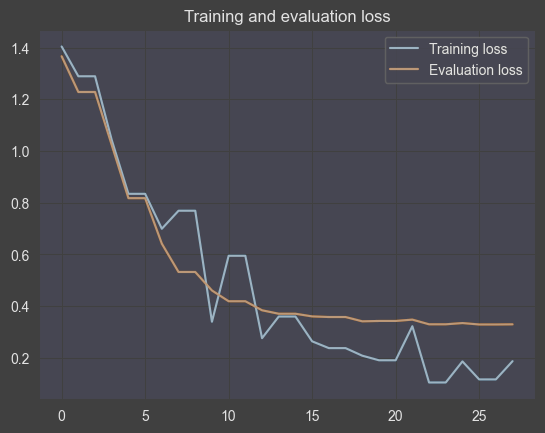
## RoBERTa Performance Metrics
              precision    recall  f1-score   support

           0       0.82      0.80      0.81       319
           1       0.88      0.90      0.89       389
           2       0.92      0.88      0.90       396
           3       0.80      0.84      0.82       394

    accuracy                           0.86       1498
    macro avg       0.86      0.86     0.86       1498
    weighted avg    0.86      0.86     0.86       1498

{'mcc': 0.8589688844097413, 'eval_loss': 0.25202705959479016}

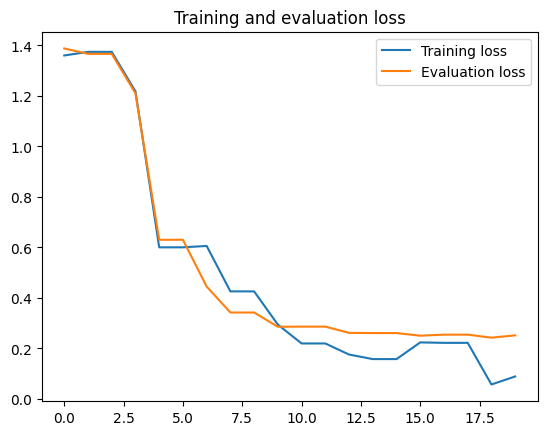
## Naive Bayes Metrics

              precision    recall  f1-score    support

           0       0.89      0.71      0.79        319
           1       0.87      0.91      0.89        389
           2       0.83      0.88      0.85        396
           3       0.81      0.85      0.83        394

    accuracy                           0.84       1498
    macro avg       0.85      0.84      0.84      1498
    weighted avg    0.85      0.84      0.84      1498
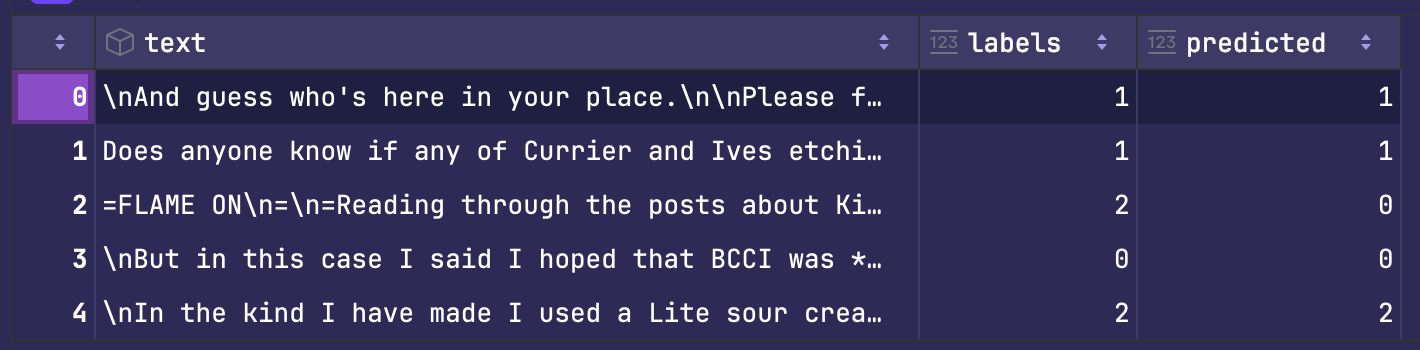

# Code for training and fine-tuning RoBERTa Model (Based on Lab 6.4)

In [ ]:
#Ran the training in Google Colab by changing the following:

#Created another copy of the 6.4 lab notebook to use the same training, development, and test partitions of the 20 newsgroups text dataset, the difference was that the classification model specified was the following
roberta_model = ClassificationModel(
    'roberta',
    'roberta-base',
    num_labels=4,
    args=model_args,
    use_cuda=True
)

#Afterwards fine-tuned the model
_, history = model.train_model(train, eval_df=dev)

#Finally, utilized the rest of the 6.4 lab notebook to evaluate the model, calculate the performance metrics, and make predictions with the model

# Code for Naive Bayes Bag of Words ML Approach

In [13]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

#Same dataset splits from Lab 6.4
categories = ['alt.atheism', 'comp.graphics', 'sci.med', 'sci.space']
newsgroups_train = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'), categories=categories, random_state=42)
newsgroups_test = fetch_20newsgroups(subset='test', remove=('headers', 'footers', 'quotes'), categories=categories, random_state=42)
train = pd.DataFrame({'text': newsgroups_train.data, 'labels': newsgroups_train.target})
test = pd.DataFrame({'text': newsgroups_test.data, 'labels': newsgroups_test.target})
train, dev = train_test_split(train, test_size=0.1, random_state=42, stratify=train['labels'])

#Bag of Words with NLTK English stopwords
nltk.download('stopwords')
stop_words_list = stopwords.words('english')
count_vect = CountVectorizer(stop_words=stop_words_list)
tfidf_transformer = TfidfTransformer()

#Transform text
X_train_counts = count_vect.fit_transform(train['text'])
X_train_tfidf = tfidf_transformer.fit_transform(X_train_counts)
X_dev_counts = count_vect.transform(dev['text'])
X_dev_tfidf = tfidf_transformer.transform(X_dev_counts)
X_test_counts = count_vect.transform(test['text'])
X_test_tfidf = tfidf_transformer.transform(X_test_counts)

#Naive Bayes Classifier (Training)
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, train['labels'])

#Evaluation and performance metrics
nb_predictions = nb_model.predict(X_test_tfidf)
print(classification_report(test['labels'], nb_predictions))

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/marianamartinez/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


              precision    recall  f1-score   support

           0       0.89      0.71      0.79       319
           1       0.87      0.91      0.89       389
           2       0.83      0.88      0.85       396
           3       0.81      0.85      0.83       394

    accuracy                           0.84      1498
   macro avg       0.85      0.84      0.84      1498
weighted avg       0.85      0.84      0.84      1498

